In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from xgboost import XGBClassifier
import shap
import pickle
from scipy import sparse

from sklearn.model_selection import TimeSeriesSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score, log_loss,
    accuracy_score, f1_score,
)

pd.set_option('display.max_rows', None)

/Users/haiming/Desktop/stats507/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Initial Analysis

## Data Loading & Cleaning

In [2]:
data = pd.read_excel('data.xls')
data.drop(columns=['FirstName', 'Email', 'VendorLeadID', 'ReferralURL', 'ReferralURL Parameters', 'Landing Page URL Parameters', 'IP Address', 'MarketingCampaign'], inplace=True)

# drop 'MarketingCampaign' because Adgroup is better structured. Missing value in MarketingCampaign and AdGroup means it's AdSense traffic from Google's content network
data['ReferralDomain'] = data['ReferralDomain'].fillna('unknown')

# keyword is ignored, as it overlap with AdGroup
# search query is ignored, as it has too many unique values and most of them are missing. Potentially we can use LLM to rank search intent and result machting.

In [3]:
print(data.columns)
print(data.shape)
print(data.isna().sum())

Index(['LeadCreated', 'CallStatus', 'WidgetName', 'PublisherZoneName',
       'PublisherCampaignName', 'AddressScore', 'PhoneScore',
       'AdvertiserCampaignName', 'State', 'DebtLevel', 'Partner',
       'ReferralDomain', 'AdGroup', 'Keyword', 'SearchQuery',
       'LandingPageURL'],
      dtype='str')
(3021, 16)
LeadCreated                  0
CallStatus                2140
WidgetName                   0
PublisherZoneName            0
PublisherCampaignName        0
AddressScore              1850
PhoneScore                1628
AdvertiserCampaignName       0
State                        0
DebtLevel                    0
Partner                      0
ReferralDomain               0
AdGroup                    272
Keyword                   2042
SearchQuery               1756
LandingPageURL               0
dtype: int64


In [4]:
# re-categorize AdGroup into more general categories

def categorize_adgroup(x):
    if pd.isna(x):
        return "content"
    x = x.lower()
    if "bankrup" in x or "chapter" in x:
        return "bankrup"
    if "student" in x:
        return "student_debt"
    if "credit" in x:
        return "credit_general"
    if "consolidat" in x:
        return "consolidation"
    if "settle" in x:
        return "settlement"
    if "loan" in x or "mortgage" in x:
        return "loan"
    if "collection" in x:
        return "collection"
    if "debt" in x:
        return "debt"
    if "content" in x:
        return "other" # content is too general, put it in other
    if "payment" in x:
        return "lower_payment"
    
    return "other"

data["AdGroup_New"] = data["AdGroup"]\
                        .fillna('content')\
                        .str.lower()\
                        .str.replace("_", " ", regex=False)\
                        .str.replace(r"\(.*?\)", "", regex=True)\
                        .str.strip().apply(categorize_adgroup)

In [5]:
# Deal with CallStatus
def map_quality(s):
    if pd.isna(s):
        return "unknown"
    if s in ["EP Sent", "EP Received", "EP Confirmed"]:
        return "good"
    if s in ["Contacted - Doesn't Qualify", "Unable to contact - Bad Contact Information", 'Contacted - Invalid Profile']:
        return "bad"
    else:
        return s.lower()

data["CallStatus"] = data["CallStatus"].apply(map_quality)
data["CallStatus"].value_counts()

CallStatus
unknown    2140
bad         488
closed      245
good        148
Name: count, dtype: int64

In [6]:
# parse WigetName
def parse_widget_name(s: str):
    """
    Return wiget size, page length, and campaign design
    """
    s = s.split('-')
    style = '-'.join(s[4:])
    return (s[1], s[3], style if style != '' else 'default')

parsed = data["WidgetName"].apply(parse_widget_name)
data["WidgetSize"] = parsed.apply(lambda x: x[0])
data["PageLength"] = parsed.apply(lambda x: x[1])
data["CampaignDesign"] = parsed.apply(lambda x: x[2])

In [7]:
data["CampaignDesign"].value_counts()

CampaignDesign
CreditSolutions     1206
default              620
white                436
yellowarrow-blue     232
BlueMeter            179
yellowarrow-dark     135
Head2                 89
Head3                 75
yellowarrow           49
Name: count, dtype: int64

In [8]:
# Parse PublisherZone
def parse_publisher_zone(s: str):
    """
    Return publisher name and zone type
    """
    s = s.split('-')
    return s[0]
data["PublisherZoneName"] = data["PublisherZoneName"].apply(parse_publisher_zone)

In [9]:
# Deal with missing values in AddressScore and PhoneScore
data['MissingAddressScore'] = data['AddressScore'].isna().astype(int)
data['MissingPhoneScore'] = data['PhoneScore'].isna().astype(int)
data['AddressScore'] = data['AddressScore'].fillna(0)
data['PhoneScore'] = data['PhoneScore'].fillna(0)

In [10]:
# normalize string content
data['Partner'] = data['Partner'].str.lower()
# merge overlap debtlevel
merge_map = {
    "7500-10000": "7500-15000",
    "10001-15000": "7500-15000",
    "7500-15000": "7500-15000",
}

data["DebtLevel"] = data["DebtLevel"].replace(merge_map)

# Visualize Trends

In [11]:
data['LeadCreated'] = pd.to_datetime(data['LeadCreated'])
data['Date'] = data['LeadCreated'].dt.date

In [12]:
data['LeadCreated']
daily_status = (
    data.groupby(["Date", "CallStatus"])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

# Total per day
daily_status["Total"] = daily_status.drop(columns=["Date"]).sum(axis=1)

# 7-day smoothing
cols = ["closed", "good", "bad", "unknown", "Total"]

for col in ["closed", "good", "bad", "unknown", "Total"]:
  daily_status[f"{col}_7d"] = daily_status[col].rolling(window=7, min_periods=7).mean()

# Plot rates (smoothed)
daily_status['closed_rate'] = daily_status['closed'] / daily_status['Total'].replace(0, np.nan)
daily_status["good_rate"] = daily_status["good"] / daily_status["Total"].replace(0, np.nan)
daily_status["bad_rate"] = daily_status["bad"] / daily_status["Total"].replace(0, np.nan)
daily_status["unknown_rate"] = daily_status["unknown"] / daily_status["Total"].replace(0, np.nan)

for col in ["closed_rate", "good_rate", "bad_rate", "unknown_rate"]:
    daily_status[f"{col}_7d"] = daily_status[col].rolling(window=7, min_periods=7).mean()


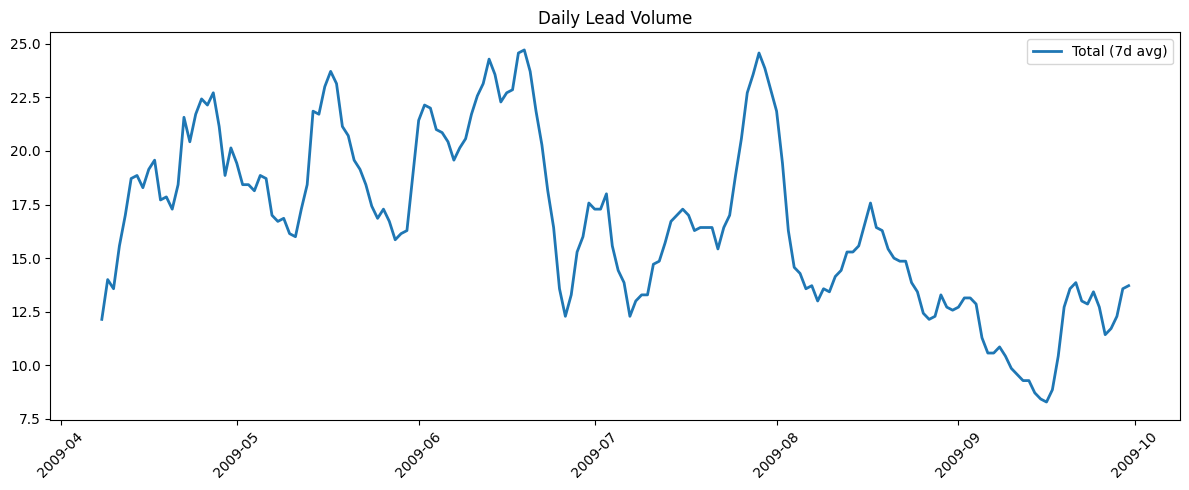

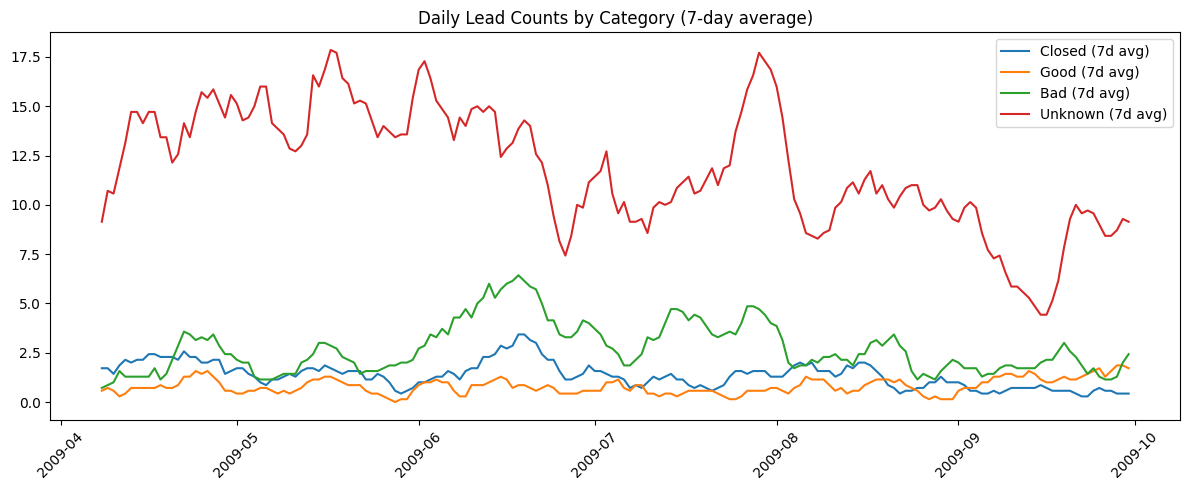

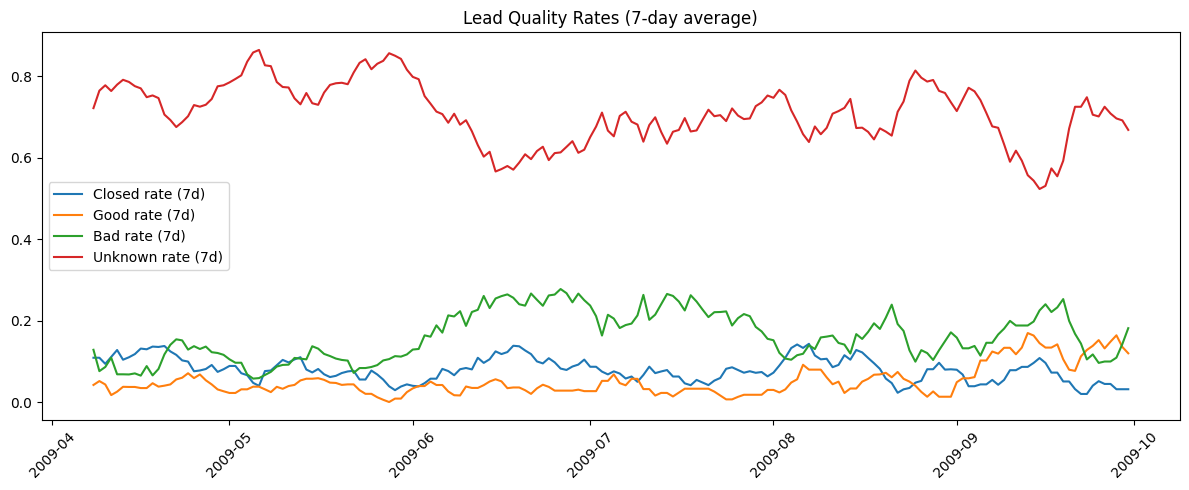

In [13]:
# Plot volume
plt.figure(figsize=(12,5))
# plt.plot(daily_status["Date"], daily_status["Total"], alpha=0.35, label="Daily Total")
plt.plot(daily_status["Date"], daily_status["Total_7d"], linewidth=2, label="Total (7d avg)")
plt.title("Daily Lead Volume")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Plot category counts (7d avg)
plt.figure(figsize=(12,5))
plt.plot(daily_status["Date"], daily_status["closed_7d"], label="Closed (7d avg)")
plt.plot(daily_status["Date"], daily_status["good_7d"], label="Good (7d avg)")
plt.plot(daily_status["Date"], daily_status["bad_7d"], label="Bad (7d avg)")
plt.plot(daily_status["Date"], daily_status["unknown_7d"], label="Unknown (7d avg)")
plt.title("Daily Lead Counts by Category (7-day average)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# Plot Rates
plt.figure(figsize=(12,5))
plt.plot(daily_status["Date"], daily_status["closed_rate_7d"], label="Closed rate (7d)")
plt.plot(daily_status["Date"], daily_status["good_rate_7d"], label="Good rate (7d)")
plt.plot(daily_status["Date"], daily_status["bad_rate_7d"], label="Bad rate (7d)")
plt.plot(daily_status["Date"], daily_status["unknown_rate_7d"], label="Unknown rate (7d)")
plt.title("Lead Quality Rates (7-day average)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# rate changes
for s in ['closed', 'good', 'unknown', 'bad']:
    rate = daily_status[f'{s}_rate_7d'].to_list()
    print(f'{s} rate changes: {(rate[-1] - rate[7])/rate[7]:03f}')

closed rate changes: -0.711133
good rate changes: 1.325435
unknown rate changes: -0.126052
bad rate changes: 1.391501


# Confirming Trends with Logistic Regression

## Volumn

In [15]:
daily_status['Date'] = pd.to_datetime(daily_status['Date'])
daily_status['TimeIndex'] = (daily_status['Date'] - daily_status['Date'].min()).dt.days
X = sm.add_constant(daily_status["TimeIndex"])

y = daily_status['Total']
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Total   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     24.05
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           2.09e-06
Time:                        23:56:44   Log-Likelihood:                -585.08
No. Observations:                 182   AIC:                             1174.
Df Residuals:                     180   BIC:                             1181.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         20.3922      0.894     22.801      0.0

## Closed

In [16]:
data["Date"] = pd.to_datetime(data["Date"])
data["TimeIndex"] = (data["Date"] - data["Date"].min()).dt.days

features = [
    "TimeIndex",
    # "AdGroup_New",
    # "Partner",
    # "WidgetSize",
    # "DebtLevel"
]
X = pd.get_dummies(data[features], drop_first=True).astype(float)

X = sm.add_constant(X)

y = data['CallStatus'].apply(lambda x: 1 if x == 'closed' else 0)

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.280306
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             CallStatus   No. Observations:                 3021
Model:                          Logit   Df Residuals:                     3019
Method:                           MLE   Df Model:                            1
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                0.004048
Time:                        23:56:44   Log-Likelihood:                -846.80
converged:                       True   LL-Null:                       -850.25
Covariance Type:            nonrobust   LLR p-value:                  0.008696
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1429      0.124    -17.283      0.000      -2.386      -1.900
TimeIndex     -0.0036      0.

## Good

In [17]:
y = data['CallStatus'].apply(lambda x: 1 if x == 'good' else 0)

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.193069
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             CallStatus   No. Observations:                 3021
Model:                          Logit   Df Residuals:                     3019
Method:                           MLE   Df Model:                            1
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                 0.01259
Time:                        23:56:44   Log-Likelihood:                -583.26
converged:                       True   LL-Null:                       -590.70
Covariance Type:            nonrobust   LLR p-value:                 0.0001147
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.5563      0.186    -19.079      0.000      -3.922      -3.191
TimeIndex      0.0065      0.

## Unkown

In [18]:
y = data['CallStatus'].apply(lambda x: 1 if x == 'unknown' else 0)

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.602116
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:             CallStatus   No. Observations:                 3021
Model:                          Logit   Df Residuals:                     3019
Method:                           MLE   Df Model:                            1
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                0.002459
Time:                        23:56:44   Log-Likelihood:                -1819.0
converged:                       True   LL-Null:                       -1823.5
Covariance Type:            nonrobust   LLR p-value:                  0.002745
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0914      0.080     13.666      0.000       0.935       1.248
TimeIndex     -0.0024      0.

## Bad

In [19]:
y = data['CallStatus'].apply(lambda x: 1 if x == 'bad' else 0)

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.440346
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             CallStatus   No. Observations:                 3021
Model:                          Logit   Df Residuals:                     3019
Method:                           MLE   Df Model:                            1
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                0.004212
Time:                        23:56:44   Log-Likelihood:                -1330.3
converged:                       True   LL-Null:                       -1335.9
Covariance Type:            nonrobust   LLR p-value:                 0.0007949
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.9334      0.101    -19.121      0.000      -2.132      -1.735
TimeIndex      0.0033      0.

Conclusion:
1. There is a statistically significant decreasing trend of 0.36% per day in closing rate
2. There is a statistically significant increasing trend of 0.65% per day in good signal rate
3. There is a statistically significant decreasing trend of 0.24% per day in unkown rate (more unkown is being classified)
4. There is a statistically significant increasing trend of 0.33% per day in bad signal rate
5. There is a statistically significant decreasing trend in lead volume

Intent signals increased, but monetization efficiency decreased. This suggest potential funnel leakage.

# Driver Deep Dive

In [20]:
# --------------------------
# 1) Target definitions
# --------------------------
data["y_closed"] = (data["CallStatus"] == "closed").astype(int)
data["y_ep_only"] = (data["CallStatus"] == "good").astype(int)
data["y_bad"] = (data["CallStatus"] == "bad").astype(int)


TARGET = "y_closed"   # change to "y_ep_only" or "y_bad" as needed

# --------------------------
# 2) Time ordering
# --------------------------
data["LeadCreated"] = pd.to_datetime(data["LeadCreated"], errors="coerce")
data = data.sort_values("LeadCreated").reset_index(drop=True)

y = data[TARGET].copy()

# --------------------------
# 3) Feature selection
# --------------------------
num_cols = ["AddressScore", "PhoneScore", "MissingAddressScore", "MissingPhoneScore"]

cat_cols = [
    "State", "Partner",
    "DebtLevel",
    "PublisherZoneName", "PublisherCampaignName",
    "AdvertiserCampaignName",
    "CampaignDesign", "PageLength",
    "AdGroup_New",
]

num_cols = [c for c in num_cols if c in data.columns]
cat_cols = [c for c in cat_cols if c in data.columns]

X = data[num_cols + cat_cols].copy()
for c in cat_cols:
    X[c] = X[c].astype("string").fillna("__MISSING__")

print(f"Loaded rows={len(data)}, features={X.shape[1]}, target={TARGET}, pos_rate={y.mean():.4f}")


Loaded rows=3021, features=13, target=y_closed, pos_rate=0.0811


CV mean performance:
n_train          1512.0000
n_test            503.0000
pos_rate_test       0.0751
roc_auc             0.6147
pr_auc              0.1102
log_loss            0.6343
accuracy@0.5        0.6298
f1@0.5              0.1827
dtype: float64
Top 20 features by mean(|SHAP|) across time folds:
                                                    mean_importance  \
cat__AdGroup_New_student_debt                              0.191300   
cat__AdGroup_New_debt                                      0.093192   
cat__DebtLevel_7500-15000                                  0.056926   
cat__State_NY                                              0.030625   
cat__State_CA                                              0.028995   
cat__DebtLevel_70001-90000                                 0.026198   
cat__Partner_google                                        0.026198   
num__PhoneScore                                            0.024071   
cat__Partner_yahoo                                        

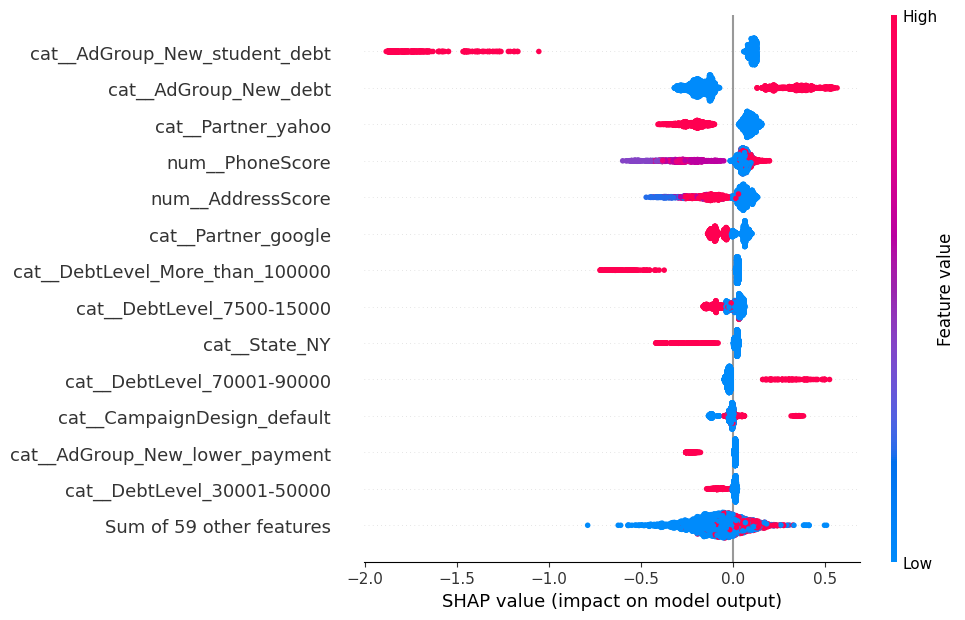

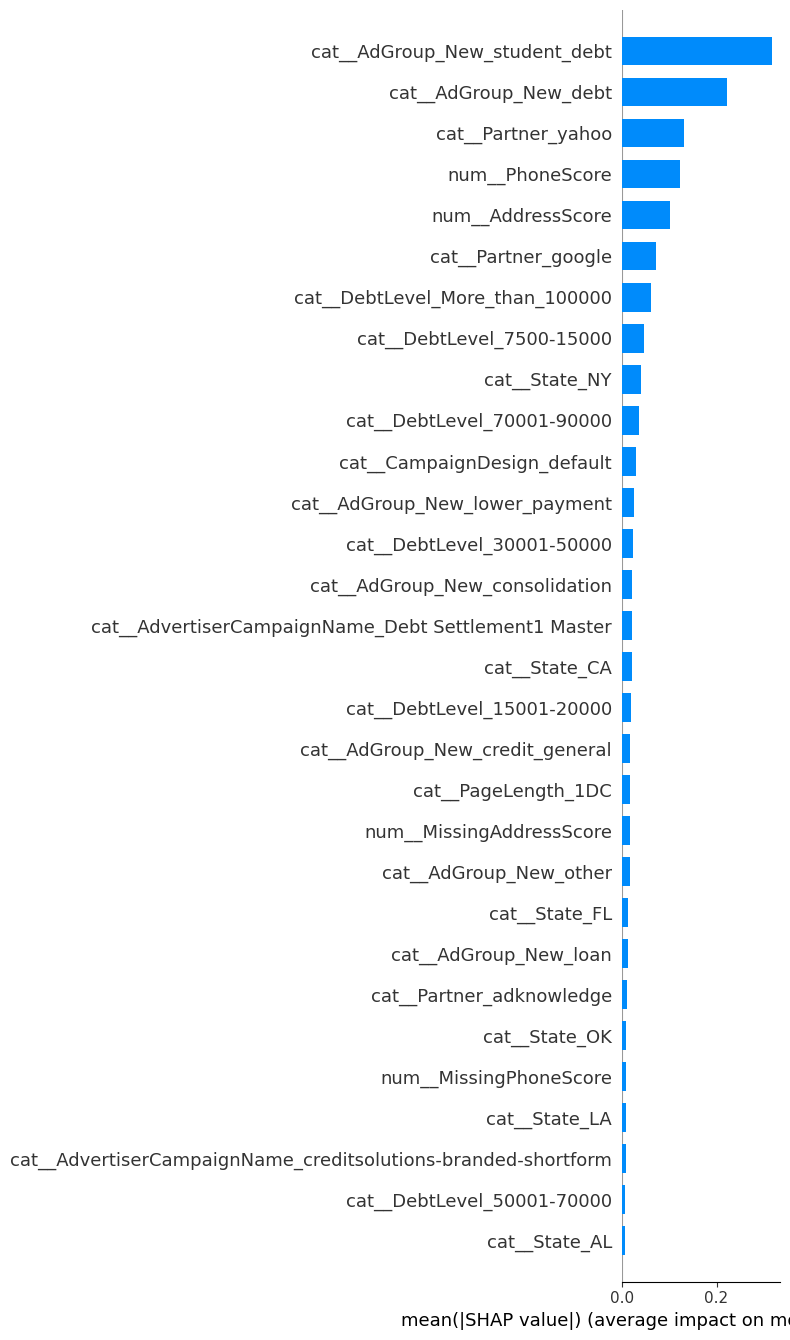

In [21]:
# Model training + CV metrics + SHAP (uses tuned hyperparameters)
# --------------------------
# 4) Preprocess + model
# --------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=20)),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop",
)

# Global class imbalance handling for full-data fit section later
pos = float(y.sum())
neg = float((1 - y).sum())
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

with open(f"./{TARGET}_best_param.pkl", "rb") as file:
    tune_output = pickle.load(file)

best_params = dict(tune_output["best_params"])
early_stopping_rounds = int(best_params.get("early_stopping_rounds", 0) or 0)
best_params.pop("early_stopping_rounds", None)

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=12312,
    scale_pos_weight=scale_pos_weight,
    **best_params,
)

pipe = Pipeline(steps=[
    ("prep", preprocess),
    ("model", xgb),
])

# --------------------------
# 5) Time-based CV + SHAP stability
# --------------------------
tscv = TimeSeriesSplit(n_splits=5)
fold_importances = []
feature_names_final = None
fold_metrics = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Match tuning script: fold-specific class weight
    pos_fold = float(y_train.sum())
    neg_fold = float((1 - y_train).sum())
    fold_scale_pos_weight = (neg_fold / pos_fold) if pos_fold > 0 else 1.0

    fold_xgb = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=42,
        scale_pos_weight=fold_scale_pos_weight,
        **best_params,
    )
    if early_stopping_rounds > 0:
        fold_xgb.set_params(early_stopping_rounds=early_stopping_rounds)

    fold_pipe = Pipeline(steps=[
        ("prep", preprocess),
        ("model", fold_xgb),
    ])

    prep = fold_pipe.named_steps["prep"]
    model = fold_pipe.named_steps["model"]

    X_train_trans = prep.fit_transform(X_train, y_train)
    X_test_trans = prep.transform(X_test)

    model.fit(
        X_train_trans,
        y_train,
        eval_set=[(X_test_trans, y_test)],
        verbose=False,
    )

    y_proba = model.predict_proba(X_test_trans)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    try:
        auc = roc_auc_score(y_test, y_proba)
    except ValueError:
        auc = np.nan

    try:
        ap = average_precision_score(y_test, y_proba)
    except ValueError:
        ap = np.nan

    ll = log_loss(y_test, y_proba, labels=[0, 1])
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    fold_metrics.append({
        "fold": fold,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "pos_rate_test": float(y_test.mean()),
        "roc_auc": auc,
        "pr_auc": ap,
        "log_loss": ll,
        "accuracy@0.5": acc,
        "f1@0.5": f1,
    })

    # print(
    #     f"Fold {fold}: "
    #     f"AUC={auc:.4f} | PR_AUC={ap:.4f} | LogLoss={ll:.4f} | "
    #     f"Acc={acc:.4f} | F1={f1:.4f} | PosRate={y_test.mean():.4f}"
    # )

    # SHAP per fold
    feature_names = prep.get_feature_names_out()
    feature_names_final = feature_names

    explainer = shap.TreeExplainer(model)
    shap_values_fold = explainer.shap_values(X_test_trans)
    if isinstance(shap_values_fold, list):
        shap_values_fold = shap_values_fold[-1]
    shap_values_fold = np.asarray(shap_values_fold)
    if shap_values_fold.ndim == 2 and shap_values_fold.shape[1] == X_test_trans.shape[1] + 1:
        shap_values_fold = shap_values_fold[:, :-1]

    mean_abs = np.mean(np.abs(shap_values_fold), axis=0)
    fold_imp = pd.Series(mean_abs, index=feature_names, name=f"fold_{fold}")
    fold_importances.append(fold_imp)

metrics_df = pd.DataFrame(fold_metrics)
print("CV mean performance:")
print(metrics_df.drop(columns=["fold"]).mean(numeric_only=True).round(4))

imp_data = pd.concat(fold_importances, axis=1).fillna(0.0)
imp_data["mean_importance"] = imp_data.mean(axis=1)
imp_data["std_importance"] = imp_data.std(axis=1)
imp_data["cv_importance"] = imp_data["std_importance"] / (imp_data["mean_importance"] + 1e-12)

top20 = imp_data.sort_values("mean_importance", ascending=False).head(30)
print("Top 20 features by mean(|SHAP|) across time folds:")
print(top20[["mean_importance", "std_importance", "cv_importance"]])

# --------------------------
# 6) Train final model on full data + SHAP summary plots
# --------------------------
def get_shap_values_2d(explainer, X_mat):
    sv = explainer.shap_values(X_mat)
    if isinstance(sv, list):
        sv = sv[-1]
    sv = np.asarray(sv)
    if sv.ndim == 2 and sv.shape[1] == X_mat.shape[1] + 1:
        sv = sv[:, :-1]
    return sv

pipe.fit(X, y)

X_trans = pipe.named_steps["prep"].transform(X)
feature_names_full = pipe.named_steps["prep"].get_feature_names_out()
booster = pipe.named_steps["model"]

explainer = shap.TreeExplainer(booster)
shap_values = get_shap_values_2d(explainer, X_trans)

assert shap_values.shape[1] == len(feature_names_full),     f"SHAP cols={shap_values.shape[1]}, names={len(feature_names_full)}"

exp = shap.Explanation(
    values=shap_values,
    data=X_trans.toarray() if hasattr(X_trans, "toarray") else X_trans,
    feature_names=feature_names_full,
)
shap.plots.beeswarm(exp, max_display=14)

shap.summary_plot(
    shap_values,
    X_trans,
    feature_names=feature_names_full,
    plot_type="bar",
    max_display=30,
)


In [22]:
if sparse.issparse(X_trans):
    X_lr = X_trans.toarray()
else:
    X_lr = np.asarray(X_trans)

X_lr_df = pd.DataFrame(X_lr, columns=feature_names_full)

# Identify one-hot groups and drop one reference level per group.
cat_prefix = "cat__"
one_hot_cols = [c for c in X_lr_df.columns if str(c).startswith(cat_prefix)]

groups = {}
cat_fields = sorted(cat_cols, key=len, reverse=True)
for col in one_hot_cols:
    rest = str(col)[len(cat_prefix):]   # e.g., AdGroup_New_debt
    matched_field = None
    for field in cat_fields:
        prefix = f"{field}_"
        if rest.startswith(prefix):
            matched_field = field
            break
    if matched_field is None:
        continue
    groups.setdefault(matched_field, []).append(col)

drop_cols = []
for field, cols in groups.items():
    # Deterministic reference level: first column in sorted order.
    ref_col = sorted(cols)[0]
    drop_cols.append(ref_col)

if drop_cols:
    X_lr_df = X_lr_df.drop(columns=drop_cols)
    print(f"Dropped {len(drop_cols)} reference dummies to avoid collinearity.")

X_lr_df = sm.add_constant(X_lr_df, has_constant="add")
y_lr = pd.Series(y).astype(float)

try:
    logit_model = sm.Logit(y_lr, X_lr_df)
    logit_result = logit_model.fit(disp=False, maxiter=300)
except Exception as e:
    print(f"Standard Logit failed ({e}). Falling back to GLM Binomial.")
    glm_model = sm.GLM(y_lr, X_lr_df, family=sm.families.Binomial())
    logit_result = glm_model.fit(maxiter=300)

print(logit_result.summary())

coef_table = pd.DataFrame({
    "feature": logit_result.params.index,
    "coef": logit_result.params.values,
}).assign(abs_coef=lambda d: d["coef"].abs())  .sort_values("abs_coef", ascending=False)

print("Top 20 coefficients by absolute value:")
print(coef_table.head(20)[["feature", "coef"]])


Dropped 9 reference dummies to avoid collinearity.
Standard Logit failed (Singular matrix). Falling back to GLM Binomial.
                 Generalized Linear Model Regression Results                  
Dep. Variable:               y_closed   No. Observations:                 3021
Model:                            GLM   Df Residuals:                     2960
Model Family:                Binomial   Df Model:                           60
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -788.98
Date:                Sun, 05 Apr 2026   Deviance:                       1578.0
Time:                        23:56:47   Pearson chi2:                 2.99e+03
No. Iterations:                    10   Pseudo R-squ. (CS):            0.03975
Covariance Type:            nonrobust                                         
                                                                    coef    std err     

In [23]:
# SHAP distribution summary per feature value
# Output: shap_distribution_by_feature[feature_name][feature_value] =
#         {min, max, median, mean, std}

if sparse.issparse(X_trans):
    X_dense = X_trans.toarray()
else:
    X_dense = np.asarray(X_trans)

shap_distribution_by_feature = {}

for j, feat in enumerate(feature_names_full):
    feat_values = X_dense[:, j]
    shap_col = np.asarray(shap_values)[:, j]

    df_feat = pd.DataFrame({
        "feature_value": feat_values,
        "shap_value": shap_col,
    })

    stats = (
        df_feat
        .groupby("feature_value", dropna=False)["shap_value"]
        .agg(["min", "max", "median", "mean", "std"])
        .reset_index()
    )

    value_summary = {}
    for _, row in stats.iterrows():
        raw_key = row["feature_value"]
        if pd.isna(raw_key):
            key = "__NaN__"
        elif isinstance(raw_key, np.generic):
            key = raw_key.item()
        else:
            key = raw_key

        value_summary[key] = {
            "min": float(row["min"]),
            "max": float(row["max"]),
            "median": float(row["median"]),
            "mean": float(row["mean"]),
            "std": float(0.0 if pd.isna(row["std"]) else row["std"]),
        }

    shap_distribution_by_feature[str(feat)] = value_summary

print(f"Built SHAP distribution dictionary for {len(shap_distribution_by_feature)} features")
# first_feature = next(iter(shap_distribution_by_feature))
# print(first_feature, shap_distribution_by_feature[first_feature])


Built SHAP distribution dictionary for 72 features


In [24]:
str(shap_distribution_by_feature)

"{'num__AddressScore': {0.0: {'min': -0.021999862045049667, 'max': 0.1344468742609024, 'median': 0.059663765132427216, 'mean': 0.06271570175886154, 'std': 0.02898460067808628}, 1.0: {'min': -0.4722016751766205, 'max': -0.24572955071926117, 'median': -0.35477420687675476, 'mean': -0.3569551110267639, 'std': 0.04926028847694397}, 2.0: {'min': -0.27719685435295105, 'max': -0.014734640717506409, 'median': -0.15990161895751953, 'mean': -0.1604747325181961, 'std': 0.06581427156925201}, 3.0: {'min': -0.3527216911315918, 'max': -0.06305360794067383, 'median': -0.19593986868858337, 'mean': -0.19932366907596588, 'std': 0.061671216040849686}, 4.0: {'min': -0.43365681171417236, 'max': -0.10490847378969193, 'median': -0.26714348793029785, 'mean': -0.2767452299594879, 'std': 0.06256842613220215}, 5.0: {'min': -0.3032436966896057, 'max': 0.029409470036625862, 'median': -0.11937909573316574, 'mean': -0.12546657025814056, 'std': 0.06298787891864777}}, 'num__PhoneScore': {0.0: {'min': -0.015027417801320

/var/folders/4d/w3tt75hn1w1d3wvtlqk0qzk00000gn/T/ipykernel_35267/112470332.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


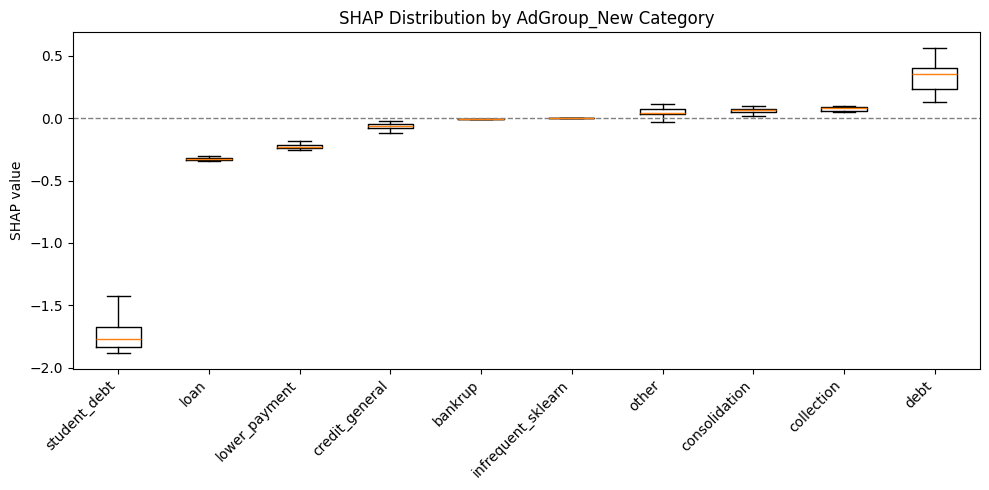

/var/folders/4d/w3tt75hn1w1d3wvtlqk0qzk00000gn/T/ipykernel_35267/112470332.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


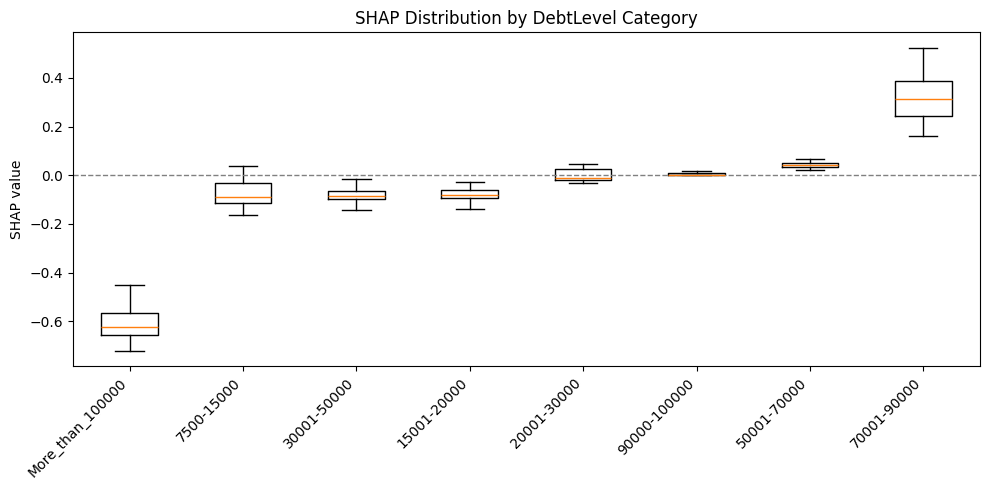

/var/folders/4d/w3tt75hn1w1d3wvtlqk0qzk00000gn/T/ipykernel_35267/112470332.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


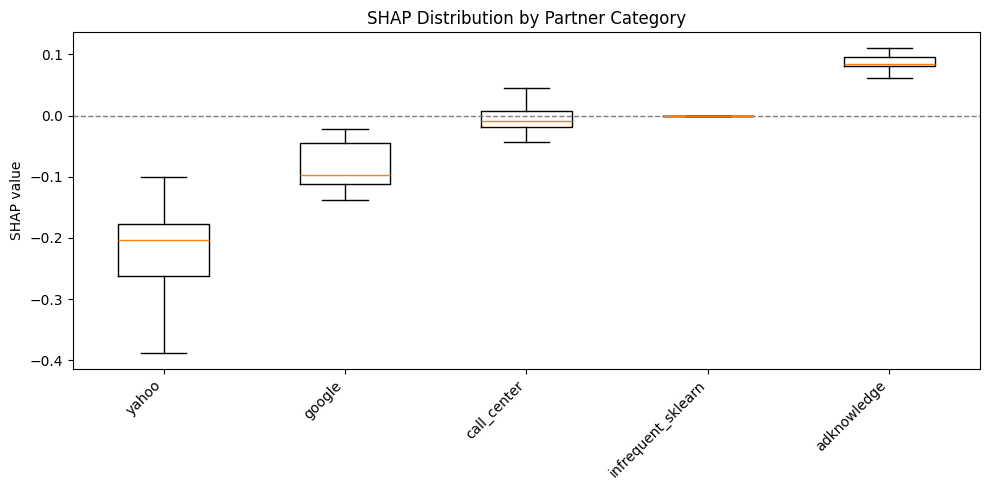

/var/folders/4d/w3tt75hn1w1d3wvtlqk0qzk00000gn/T/ipykernel_35267/112470332.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


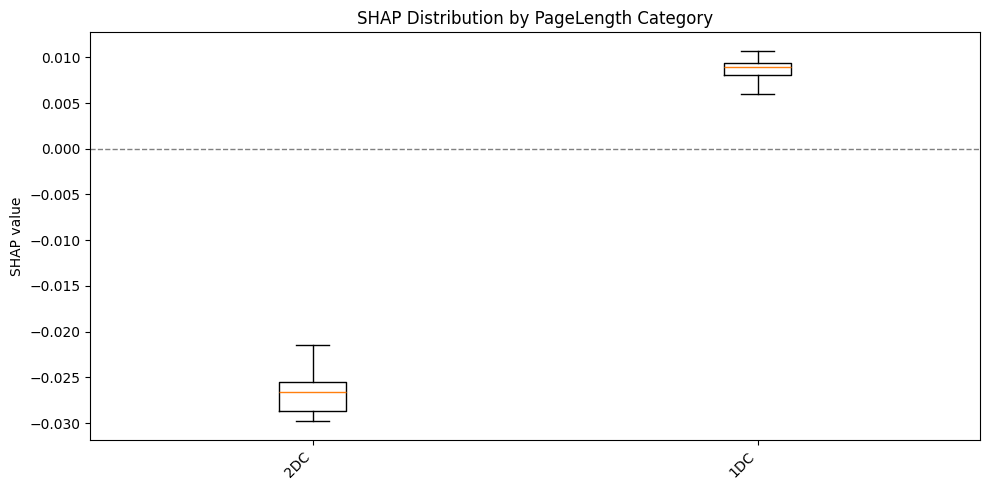

/var/folders/4d/w3tt75hn1w1d3wvtlqk0qzk00000gn/T/ipykernel_35267/112470332.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


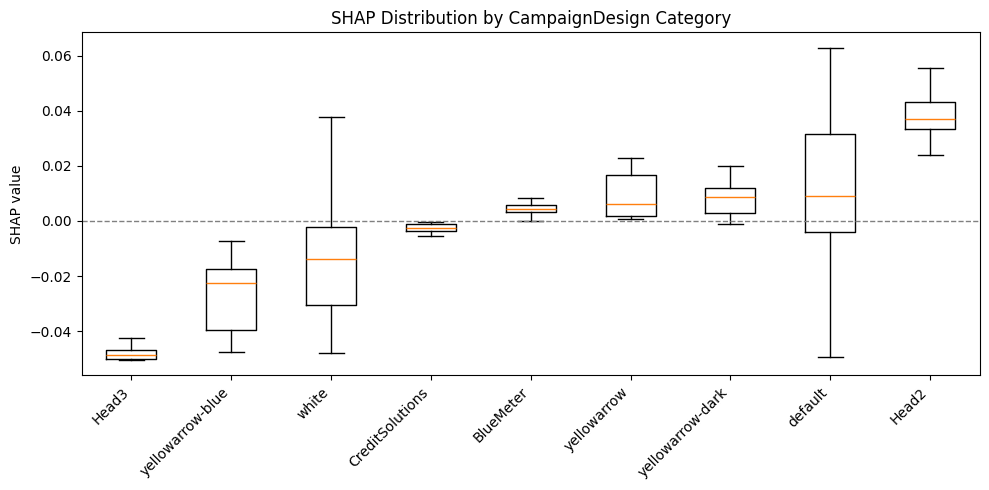

/var/folders/4d/w3tt75hn1w1d3wvtlqk0qzk00000gn/T/ipykernel_35267/112470332.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


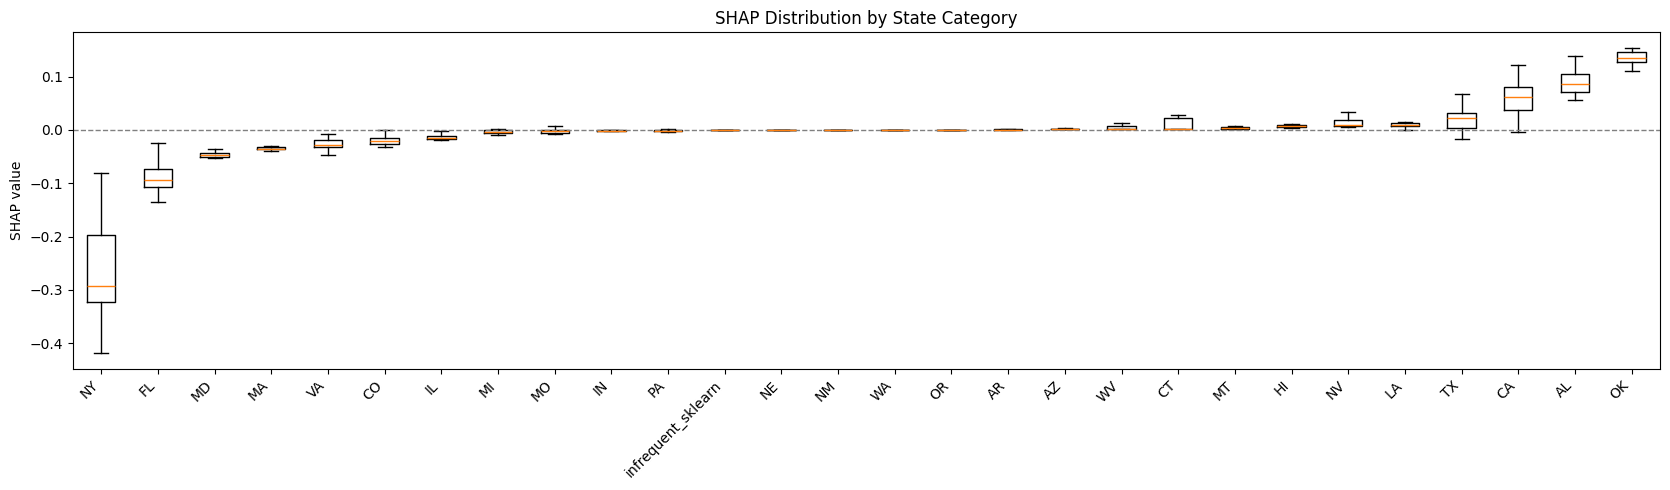

In [25]:
# Category-level SHAP boxplots for one-hot encoded fields
# Plots SHAP distributions only where each one-hot column equals 1.

one_hot_fields = ["AdGroup_New", "DebtLevel", "Partner", "PageLength", "CampaignDesign", "State"]

if sparse.issparse(X_trans):
    X_dense = X_trans.toarray()
else:
    X_dense = np.asarray(X_trans)

shap_arr = np.asarray(shap_values)
feat_names = np.asarray(feature_names_full)

for field in one_hot_fields:
    prefix = f"cat__{field}_"
    idxs = [i for i, name in enumerate(feat_names) if str(name).startswith(prefix)]

    if not idxs:
        print(f"Skipped {field}: no one-hot columns found")
        continue

    records = []
    for idx in idxs:
        col_name = str(feat_names[idx])
        category = col_name[len(prefix):]

        mask = X_dense[:, idx] == 1
        vals = shap_arr[mask, idx]

        if vals.size == 0:
            continue

        records.append((category, vals))

    if not records:
        print(f"Skipped {field}: no rows with one-hot value == 1")
        continue

    # Sort categories by median SHAP so comparisons are easier to read.
    records = sorted(records, key=lambda x: np.median(x[1]))
    labels = [r[0] for r in records]
    box_data = [r[1] for r in records]

    plt.figure(figsize=(max(10, 0.6 * len(labels)), 5))
    plt.boxplot(box_data, labels=labels, showfliers=False)
    plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
    plt.title(f"SHAP Distribution by {field} Category")
    plt.ylabel("SHAP value")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


/var/folders/4d/w3tt75hn1w1d3wvtlqk0qzk00000gn/T/ipykernel_35267/3283048730.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


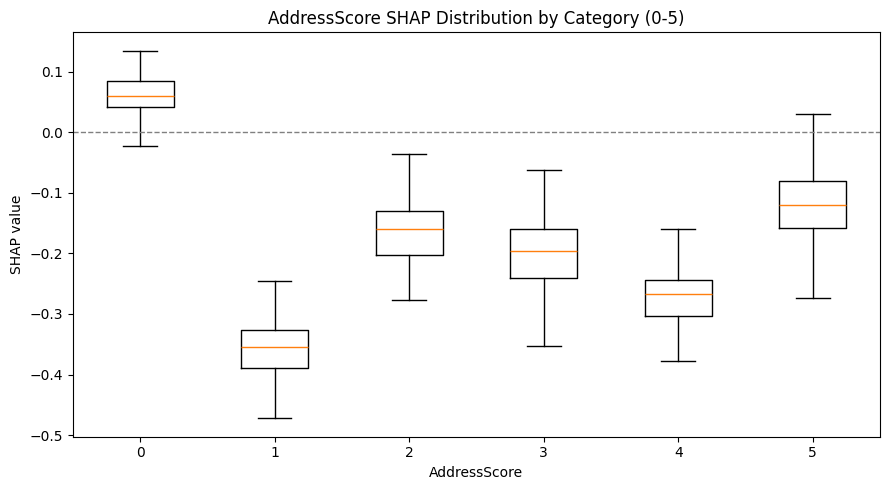

/var/folders/4d/w3tt75hn1w1d3wvtlqk0qzk00000gn/T/ipykernel_35267/3283048730.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


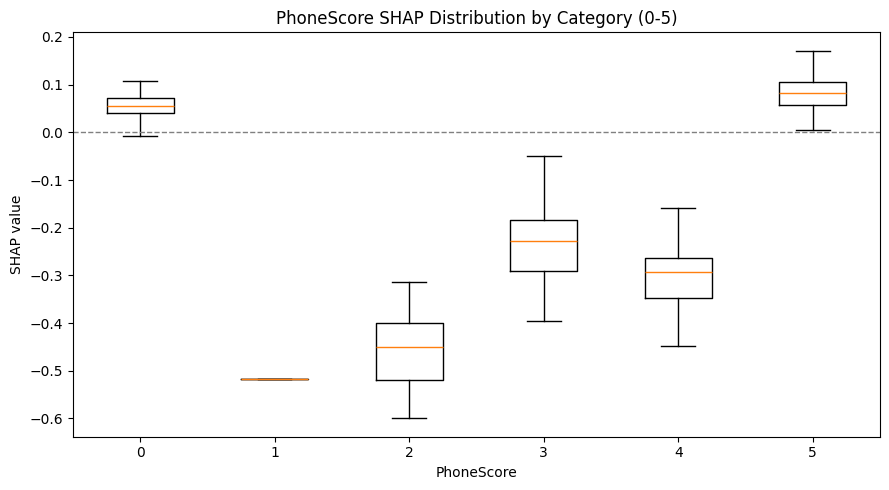

In [26]:
# SHAP boxplots for AddressScore and PhoneScore categories (0-5)

if sparse.issparse(X_trans):
    X_dense = X_trans.toarray()
else:
    X_dense = np.asarray(X_trans)

shap_arr = np.asarray(shap_values)
feature_name_to_idx = {str(name): i for i, name in enumerate(feature_names_full)}

score_features = ["AddressScore", "PhoneScore"]
score_levels = [0, 1, 2, 3, 4, 5]

for feat in score_features:
    feat_key = f"num__{feat}"
    if feat_key not in feature_name_to_idx:
        print(f"Skipped {feat}: transformed feature '{feat_key}' not found")
        continue

    idx = feature_name_to_idx[feat_key]
    x_vals = pd.to_numeric(X_dense[:, idx], errors="coerce")
    shap_vals = shap_arr[:, idx]

    box_data = []
    labels = []
    for lvl in score_levels:
        mask = np.isclose(x_vals, lvl, equal_nan=False)
        vals = shap_vals[mask]
        if vals.size > 0:
            box_data.append(vals)
            labels.append(str(lvl))

    if not box_data:
        print(f"Skipped {feat}: no rows for categories 0-5")
        continue

    plt.figure(figsize=(9, 5))
    plt.boxplot(box_data, labels=labels, showfliers=False)
    plt.axhline(0.0, color="gray", linestyle="--", linewidth=1)
    plt.title(f"{feat} SHAP Distribution by Category (0-5)")
    plt.xlabel(feat)
    plt.ylabel("SHAP value")
    plt.tight_layout()
    plt.show()


# Action Trend Analysis

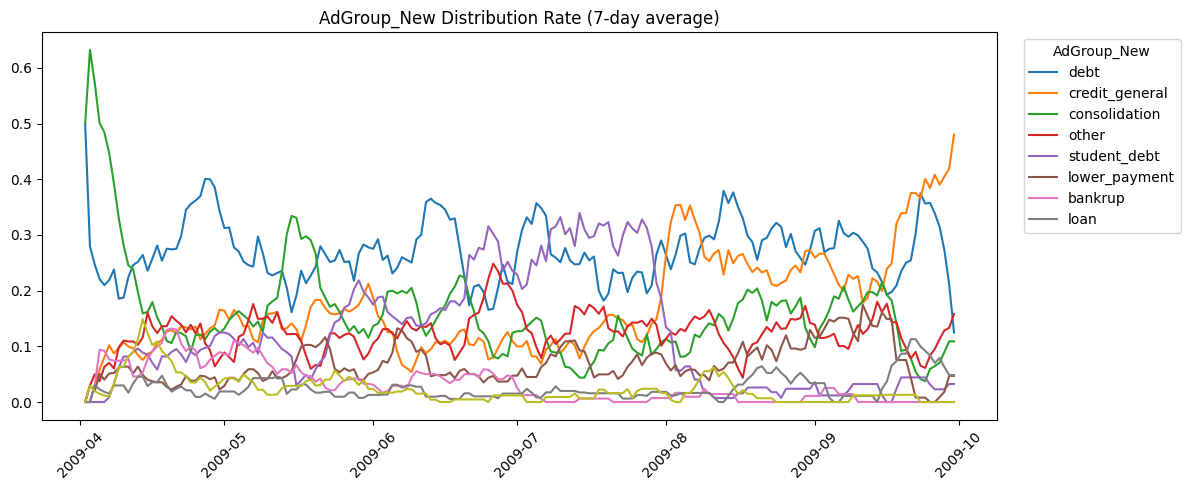

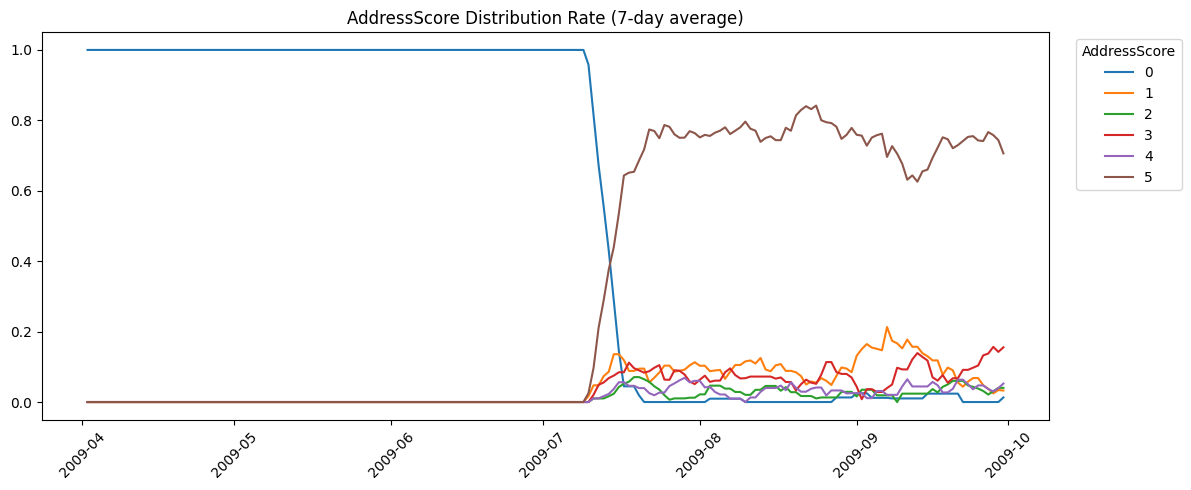

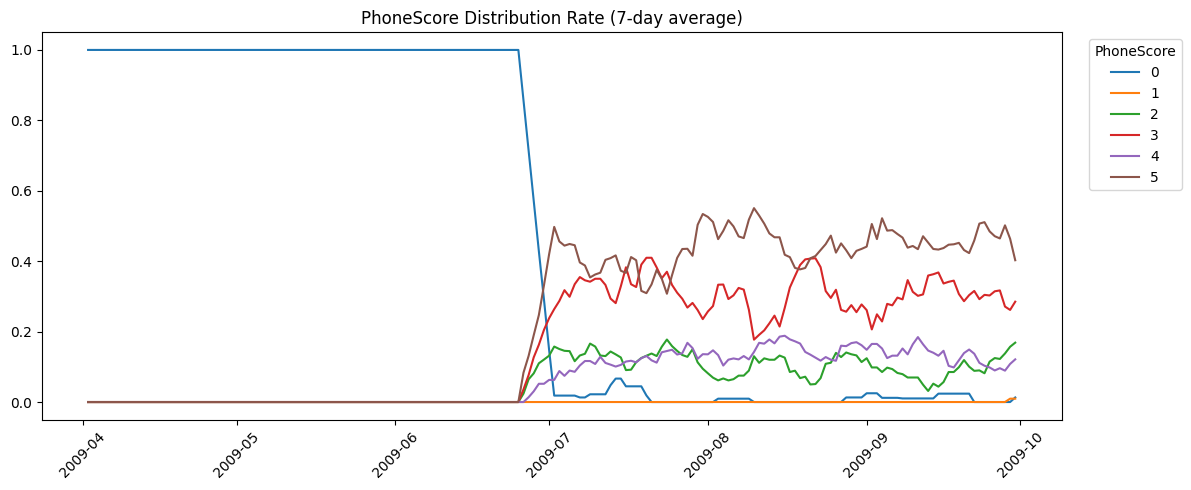

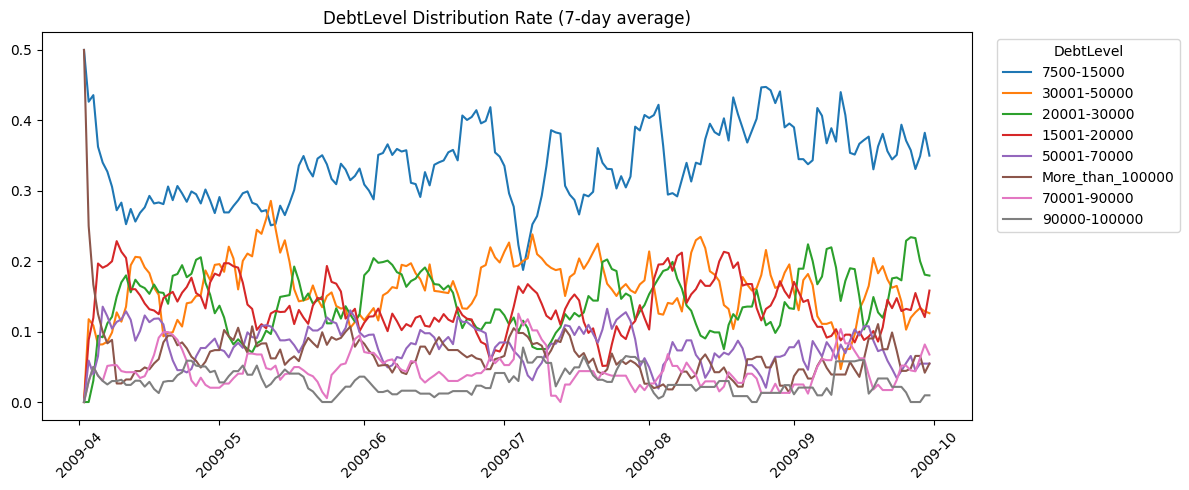

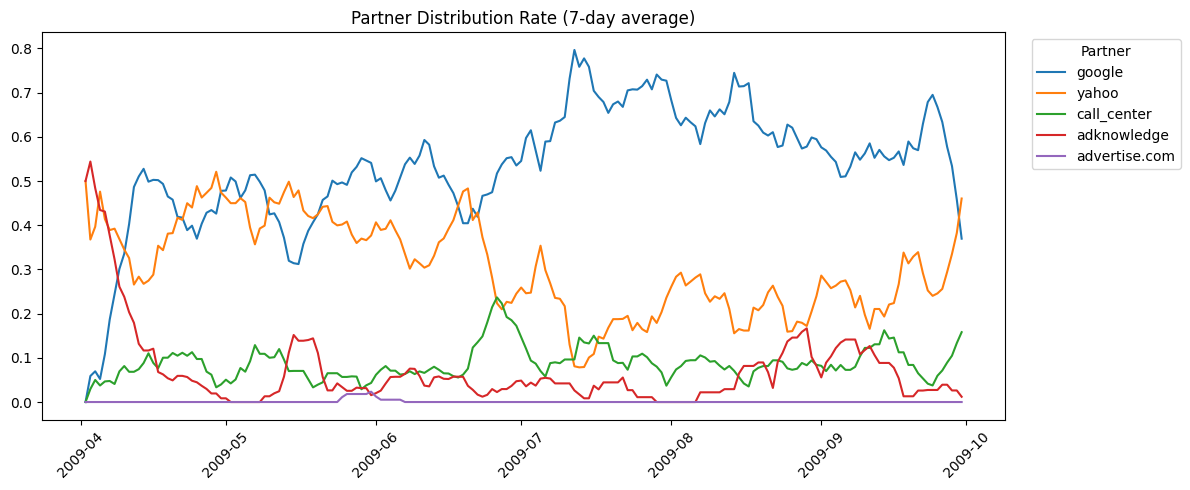

In [27]:
# 7-day rolling average distribution rates (line plots)
plot_df = data.copy()
plot_df["Date"] = pd.to_datetime(plot_df["LeadCreated"], errors="coerce").dt.floor("D")
plot_df = plot_df.dropna(subset=["Date"])


def plot_feature_distribution_rate_7d(
    df: pd.DataFrame,
    feature: str,
    date_col: str = "Date",
    top_k: int = 8,
    bins: int = 10,
    max_lines: int = 12,
):
    tmp = df[[date_col, feature]].copy()

    categorical_score_features = {"AddressScore", "PhoneScore"}

    if feature in categorical_score_features:
        # Treat score as categorical with fixed levels 0-5.
        score = pd.to_numeric(tmp[feature], errors="coerce").round()
        score = score.where(score.isin([0, 1, 2, 3, 4, 5]), np.nan)
        tmp["feature_value"] = score.map(lambda x: str(int(x)) if pd.notna(x) else "__MISSING__")
    elif pd.api.types.is_numeric_dtype(tmp[feature]):
        # Use quantile bins for other numeric features to keep plots interpretable.
        unique_n = tmp[feature].nunique(dropna=True)
        bin_count = int(min(bins, max(2, unique_n))) if unique_n > 1 else 2
        try:
            tmp["feature_value"] = pd.qcut(tmp[feature], q=bin_count, duplicates="drop").astype("string")
        except ValueError:
            tmp["feature_value"] = pd.cut(tmp[feature], bins=bin_count, duplicates="drop").astype("string")
    else:
        tmp["feature_value"] = tmp[feature].astype("string").fillna("__MISSING__")

    if feature in categorical_score_features:
        keep = ["0", "1", "2", "3", "4", "5", "__MISSING__"]
        tmp["feature_value"] = tmp["feature_value"].where(tmp["feature_value"].isin(keep), "__OTHER__")
    else:
        vc = tmp["feature_value"].value_counts(dropna=False)
        keep = vc.head(top_k).index
        tmp["feature_value"] = tmp["feature_value"].where(tmp["feature_value"].isin(keep), "__OTHER__")

    daily_counts = (
        tmp.groupby([date_col, "feature_value"]).size().rename("count").reset_index()
    )
    daily_total = (
        tmp.groupby(date_col).size().rename("total").reset_index()
    )

    daily_rate = daily_counts.merge(daily_total, on=date_col, how="left")
    daily_rate["rate"] = daily_rate["count"] / daily_rate["total"].replace(0, np.nan)

    pivot = (
        daily_rate
        .pivot(index=date_col, columns="feature_value", values="rate")
        .sort_index()
        .fillna(0.0)
    )

    pivot_7d = pivot.rolling(window=7, min_periods=1).mean()

    # Control line ordering/selection.
    if feature in categorical_score_features:
        ordered = [c for c in ["0", "1", "2", "3", "4", "5", "__MISSING__", "__OTHER__"] if c in pivot_7d.columns]
        chosen = ordered
    else:
        freq_order = pivot.sum(axis=0).sort_values(ascending=False).index.tolist()
        chosen = freq_order[:max_lines]
        if "__OTHER__" in pivot_7d.columns and "__OTHER__" not in chosen:
            if len(chosen) >= max_lines:
                chosen = chosen[:-1]
            chosen.append("__OTHER__")

    plt.figure(figsize=(12, 5))
    for col in chosen:
        if col in pivot_7d.columns:
            plt.plot(pivot_7d.index, pivot_7d[col], label=str(col))

    plt.title(f"{feature} Distribution Rate (7-day average)")
    plt.xticks(rotation=45)
    plt.legend(title=feature, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


for feat in ["AdGroup_New", "AddressScore", "PhoneScore", "DebtLevel", "Partner"]:
    if feat in plot_df.columns:
        plot_feature_distribution_rate_7d(plot_df, feat)
    else:
        print(f"Skipped {feat}: column not found")
